In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
train_dir = "/content/drive/MyDrive/AI and ML/Week-5/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI and ML/Week-5/FruitinAmazon/test"

Classes: ['acai', 'tucuma', 'pupunha', 'cupuacu', 'guarana', 'graviola']


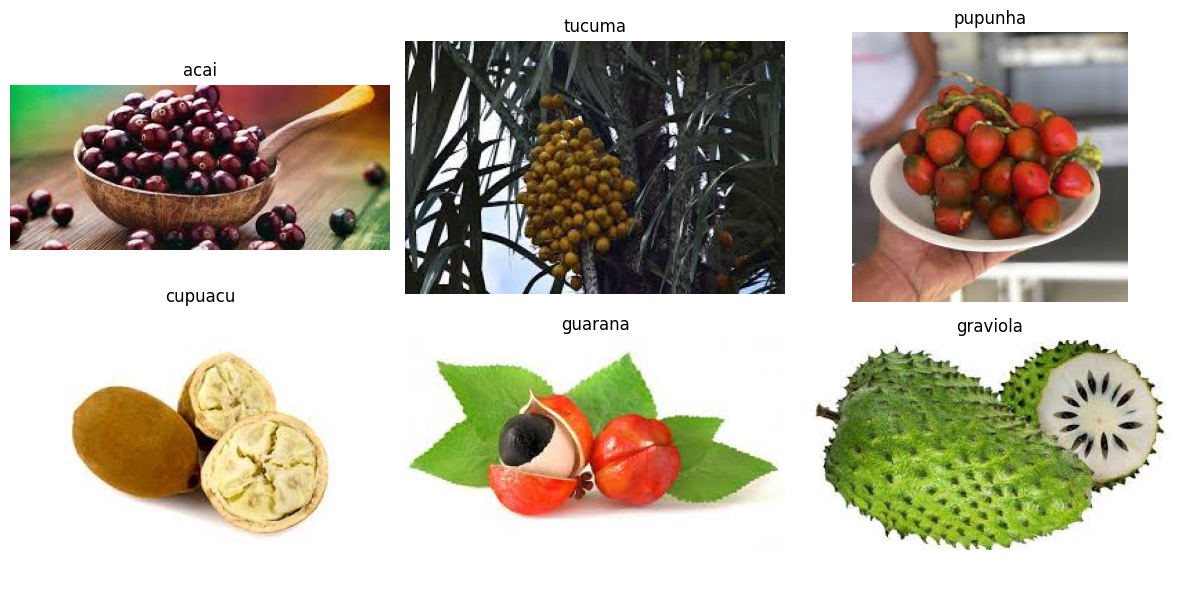

In [4]:
# Get class names
classes = os.listdir(train_dir)
print("Classes:", classes)

# Select one random image per class
images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

# Plot images (2 rows grid)
cols = len(images) // 2 + len(images) % 2

plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, cols, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:

corrupted = []

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()   # check if corrupted
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


In [6]:

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [7]:
num_classes = len(os.listdir(train_dir))

model = keras.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Fully connected
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
callbacks = [
    ModelCheckpoint("fruit_cnn_model.h5", save_best_only=True, monitor='val_loss'),
    EarlyStopping(monitor='val_loss', patience=10)
]

print("Model compiled and callbacks are ready!")

Model compiled and callbacks are ready!


In [9]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=callbacks
)

print("Training completed!")

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.1649 - loss: 1.8062

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 813ms/step - accuracy: 0.1667 - loss: 1.8338 - val_accuracy: 0.0556 - val_loss: 2.2188
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.2662 - loss: 1.7400

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 869ms/step - accuracy: 0.2361 - loss: 1.7792 - val_accuracy: 0.5556 - val_loss: 1.4011
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 697ms/step - accuracy: 0.3889 - loss: 1.5184 - val_accuracy: 0.5556 - val_loss: 1.6763
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.3484 - loss: 1.4803

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 536ms/step - accuracy: 0.3889 - loss: 1.4162 - val_accuracy: 0.7778 - val_loss: 1.1679
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.6256 - loss: 1.1144

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 617ms/step - accuracy: 0.6111 - loss: 1.1082 - val_accuracy: 0.3889 - val_loss: 0.9328
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.5694 - loss: 0.9929 - val_accuracy: 0.5556 - val_loss: 1.3327
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 0.6806 - loss: 0.8404 - val_accuracy: 0.7778 - val_loss: 1.0244
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.7396 - loss: 0.7557

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 528ms/step - accuracy: 1.0000 - loss: 0.1669 - val_accuracy: 0.8333 - val_loss: 0.5342
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9595 - loss: 0.1489

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 523ms/step - accuracy: 0.9722 - loss: 0.1275 - val_accuracy: 0.7222 - val_loss: 0.5303
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9699 - loss: 0.0735

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 506ms/step - accuracy: 0.9722 - loss: 0.0737 - val_accuracy: 0.8889 - val_loss: 0.4290
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 771ms/step - accuracy: 1.0000 - loss: 0.0354 - val_accuracy: 0.8889 - val_loss: 0.5307
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - loss: 0.0451

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 1.0000 - loss: 0.0378 - val_accuracy: 0.8889 - val_loss: 0.3164
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 1.0000 - loss: 0.0115

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 1.0000 - loss: 0.0117 - val_accuracy: 0.8889 - val_loss: 0.2794
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 466ms/step - accuracy: 1.0000 - loss: 0.0129 - val_accuracy: 0.9444 - val_loss: 0.2846
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 679ms/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 0.8889 - val_loss: 0.3149
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 1.0000 - loss: 0.0050 - val_accuracy: 0.8889 - val_loss: 0.3820
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 819ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.8889 - val_loss: 0.4080
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 865ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.8889 - val_loss: 0.4138
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8889 - val_loss: 0.4111
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 541ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8889 - val_loss: 0.

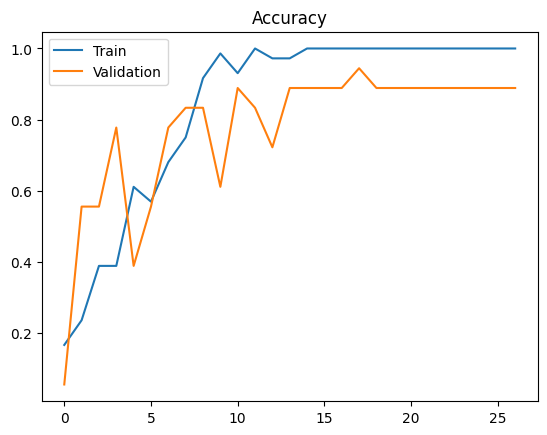

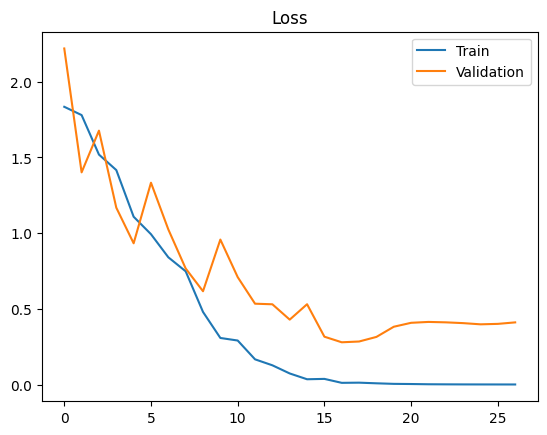

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step - accuracy: 0.8889 - loss: 0.4108
Test Accuracy: 0.8888888955116272
Test Loss: 0.4107891917228699


In [12]:
from tensorflow.keras.models import load_model

# Save the trained model
model.save("fruit_classifier_model.h5")
print("Model saved as fruit_classifier_model.h5")



Model saved as fruit_classifier_model.h5


In [13]:
# Load the saved model
loaded_model = load_model("fruit_classifier_model.h5")
print("Model loaded successfully!")

# Compile the loaded model to properly build metrics
loaded_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Create the test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False # Test data should not be shuffled
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Re-evaluate on test set
test_loss, test_acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model Test Loss: {test_loss:.4f}")
print(f"Loaded Model Test Accuracy: {test_acc:.4f}")

Model loaded successfully!
Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6000 - loss: 1.5148
Loaded Model Test Loss: 1.5148
Loaded Model Test Accuracy: 0.6000


In [14]:
import numpy as np
from sklearn.metrics import classification_report

# Lists to store true labels and predictions
y_true = []
y_pred = []

# Loop through test dataset
for images, labels in test_ds:
    preds = loaded_model.predict(images)  # predicted probabilities
    preds = np.argmax(preds, axis=1)      # convert to class labels

    y_true.extend(labels.numpy())         # actual labels
    y_pred.extend(preds)                  # predicted labels

# Print Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.60      0.60      0.60         5
      tucuma       0.43      0.60      0.50         5
     pupunha       0.62      1.00      0.77         5
     cupuacu       0.50      0.60      0.55         5
     guarana       1.00      0.40      0.57         5
    graviola       1.00      0.40      0.57         5

    accuracy                           0.60        30
   macro avg       0.69      0.60      0.59        30
weighted avg       0.69      0.60      0.59        30



Week-6:

In [15]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

In [16]:
model = keras.Sequential([

    layers.Input(shape=(128,128,3)),

    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 4 (Deeper model)
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Fully Connected Layers
    layers.Flatten(),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2037 - loss: 2.4484

3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.2361 - loss: 2.3164 - val_accuracy: 0.0000e+00 - val_loss: 1.7860
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.3472 - loss: 1.9061 - val_accuracy: 0.0000e+00 - val_loss: 1.8239
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3611 - loss: 1.7044 - val_accuracy: 0.0000e+00 - val_loss: 1.9518
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4444 - loss: 1.5249 - val_accuracy: 0.0000e+00 - val_loss: 2.1460
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4444 - loss: 1.5787 - val_accuracy: 0.0000e+00 - val_loss: 2.3242
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.4028 - loss: 1.5153 - val_accuracy: 0.0000e+00 - val_loss: 2.5614
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.5556 - loss: 1.1998 - val_accuracy: 0.0000e+00 - val_loss: 2.8917
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5694 - loss: 1.2439 - val_accuracy: 0.0000e+00 - val_loss

In [18]:
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             

 Total params: 26,741,204 (102.01 MB)

 Trainable params: 8,912,902 (34.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

 Optimizer params: 17,825,806 (68.00 MB)

In [19]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.60      0.60      0.60         5
      tucuma       0.43      0.60      0.50         5
     pupunha       0.62      1.00      0.77         5
     cupuacu       0.50      0.60      0.55         5
     guarana       1.00      0.40      0.57         5
    graviola       1.00      0.40      0.57         5

    accuracy                           0.60        30
   macro avg       0.69      0.60      0.59        30
weighted avg       0.69      0.60      0.59        30



Fine Tuining

In [20]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(img_height, img_width, 3) # Changed input_shape to match dataset
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
for layer in base_model.layers:
    layer.trainable = False

In [22]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(num_classes, activation='softmax')(x)

In [23]:
from tensorflow.keras.models import Model

model = Model(inputs=base_model.input, outputs=x)

In [24]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.2083 - loss: 1.9259 - val_accuracy: 0.3333 - val_loss: 1.4637
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.3333 - loss: 1.5179 - val_accuracy: 0.6667 - val_loss: 1.3153
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.4444 - loss: 1.3575 - val_accuracy: 0.6111 - val_loss: 1.2647
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 7s/step - accuracy: 0.7083 - loss: 1.0856 - val_accuracy: 0.7222 - val_loss: 0.9885
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 7s/step - accuracy: 0.7778 - loss: 0.9579 - val_accuracy: 0.6111 - val_loss: 0.8373
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.7917 - loss: 0.8159 - val_accuracy: 0.6111 - val_loss: 0.9092
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.8194 - loss: 0.7092 - val_accuracy: 0.6111 - val_loss: 0.9446
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.8889 - loss: 0.6078 - val_accuracy: 0.6111 - val_loss: 0.9664
Epoch 9/

In [25]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.8889 - loss: 0.3061
Validation Accuracy: 0.8888888955116272
Validation Loss: 0.3061027526855469


In [29]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())   # for sparse labels
    y_pred.extend(preds)

print("Sample Predictions:", y_pred[:10])

Sample Predictions: [np.int64(4), np.int64(5), np.int64(4), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5)]


In [27]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes, labels=list(range(num_classes))))

Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
      tucuma       0.00      0.00      0.00         0
     pupunha       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
     guarana       1.00      0.67      0.80         3
    graviola       0.93      0.93      0.93        15

    accuracy                           0.89        18
   macro avg       0.32      0.27      0.29        18
weighted avg       0.94      0.89      0.91        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

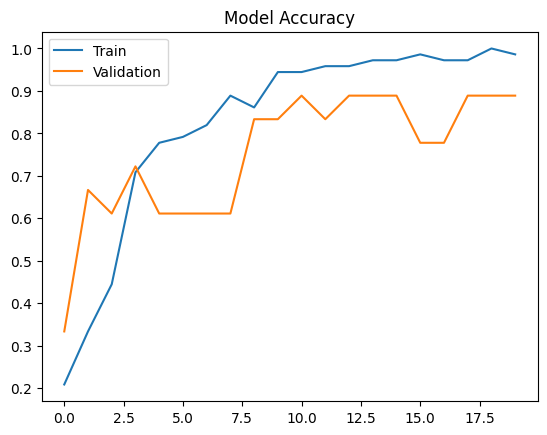

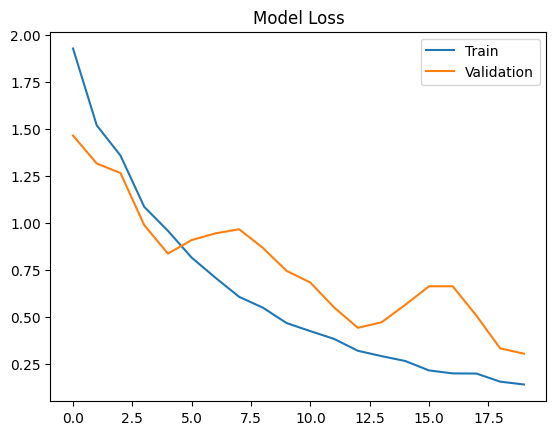

In [28]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()